> metrics of diseases perhaps include persistent homology here applied to on SCLC that shows geometrically why its a chemotherapy escaping disease. Equally weighted distributions (SCLC COLless imbalance)

In [1]:
import os, sys, json
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_tied_linear_reconstruct/"
sys.path.append('../../')
from polygene.model.model import load_trained_model

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-2) # highest performance model

from polygene.data_utils.tokenization import normalise_str
frequent_diseases = [normalise_str(d) for d in json.load(open('/media/lleger/LaCie/mit/disease_geometry/diseases.json'))['diseases']]
disease_indices_in_embedding_matrix = [tokenizer.token_to_id_map[d] for d in frequent_diseases]
disease_embeddings = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()[disease_indices_in_embedding_matrix]
print(disease_embeddings.shape)

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(50, 240)


Bbox(x0=0.813888888888889, y0=0.10999999999999999, x1=0.8655555555555556, y1=0.88)


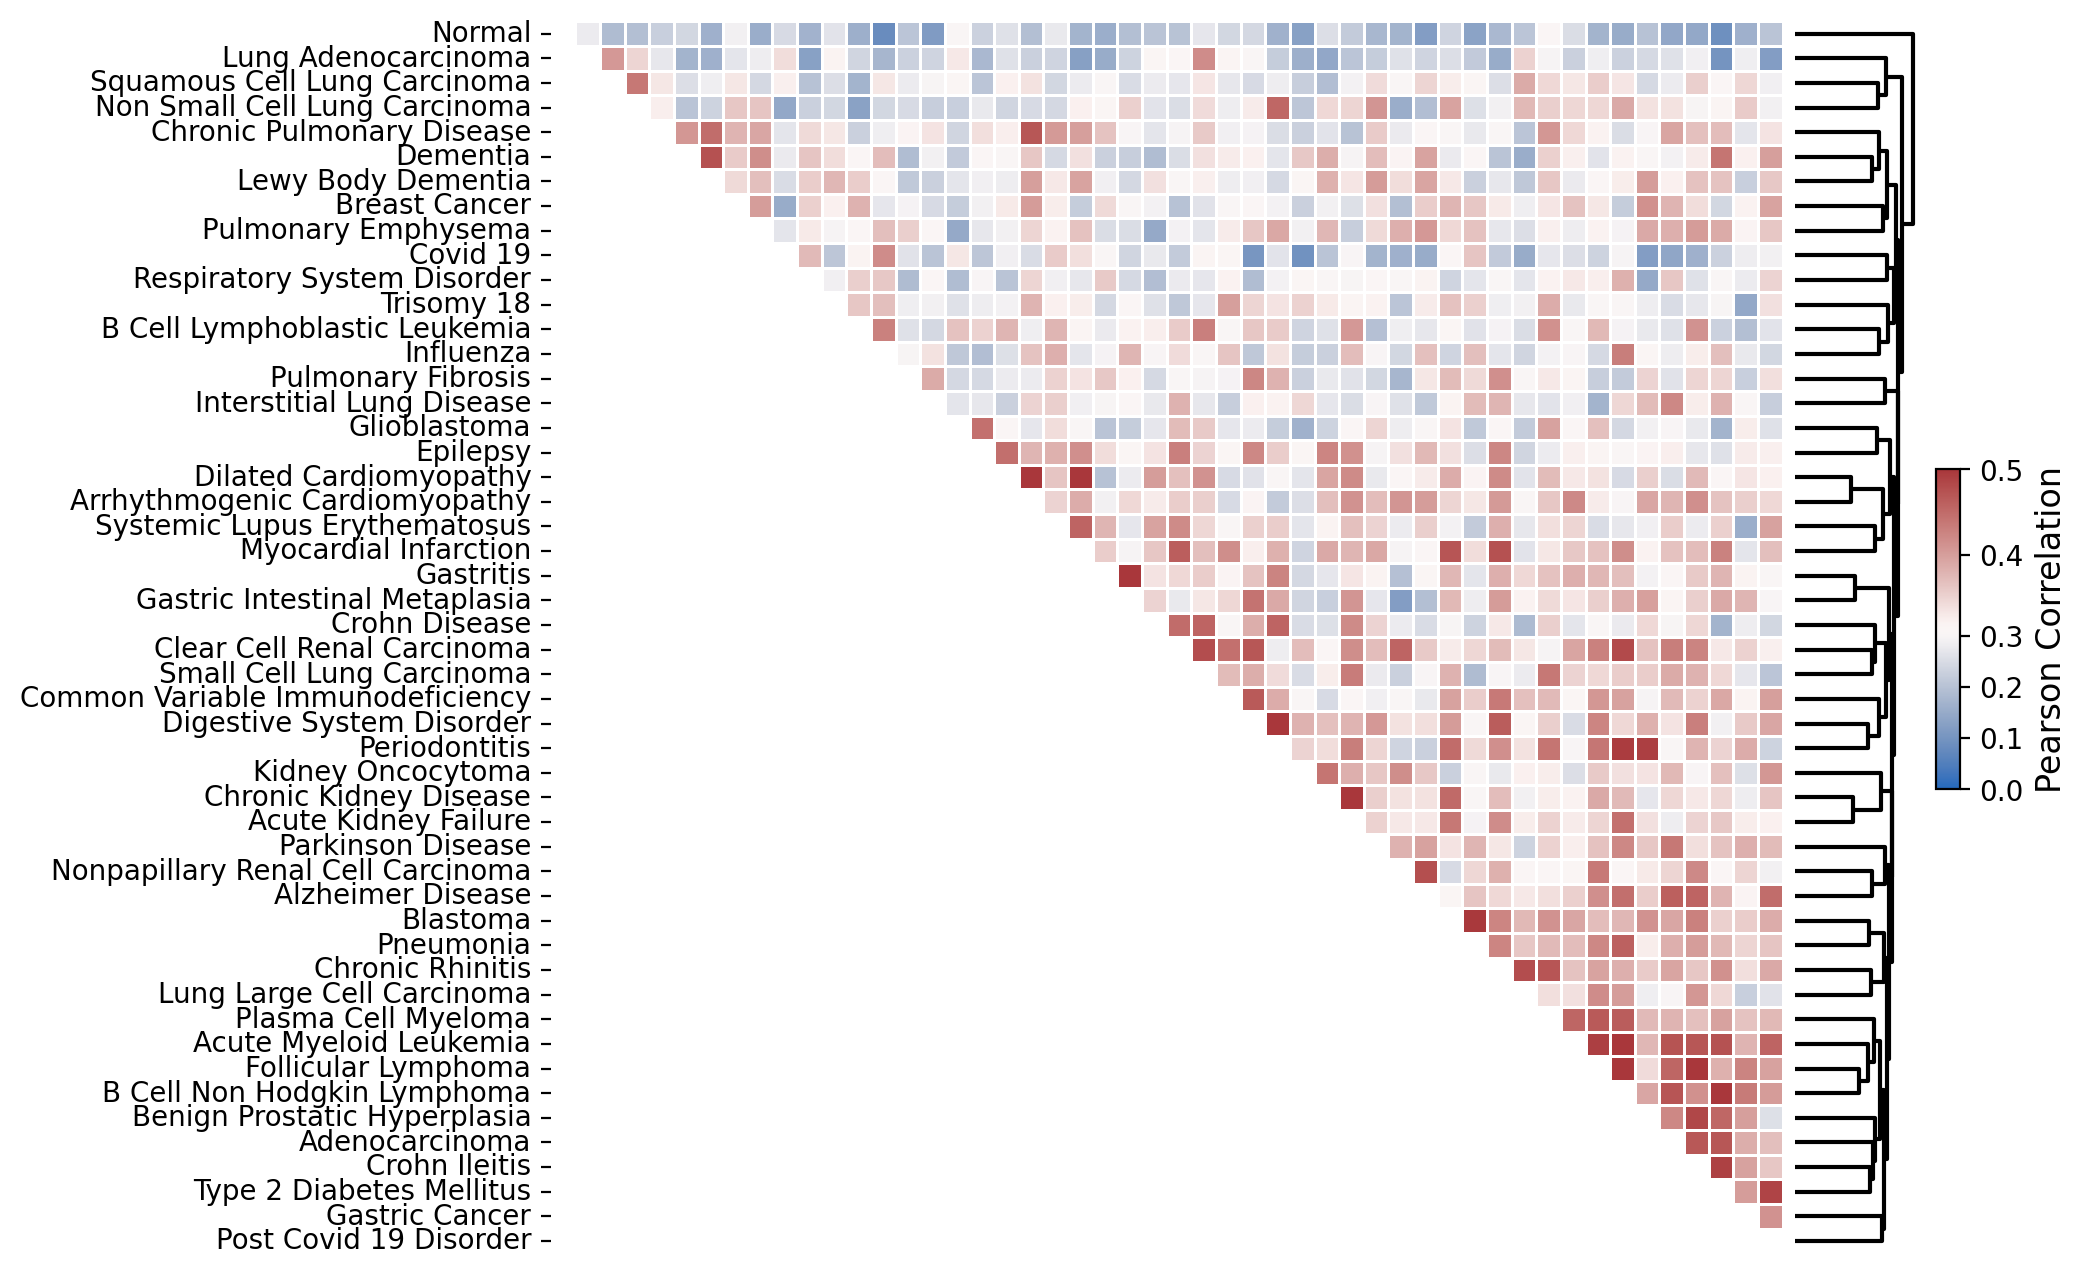

In [ ]:
# Showing semantic organisation and phenomenology of disease landscape and foundation model geometry
from scipy.spatial.distance import pdist
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram

def plot_correlation_matrix(data, labels, palette='vlag', figsize=(12,8), dpi=200, fontsize=14,  save_path=None):
    

    x = cosine_similarity(data)
    pairwise_distance_matrix = pdist(data, metric="cosine")
    row_link = linkage(pairwise_distance_matrix, method="average")
    order = leaves_list(row_link)
    corr = x[np.ix_(order, order)].copy()
    corr[np.tril_indices_from(corr, 0)] = np.nan

    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(1, 3, width_ratios=(10, 0.75, 0.5), wspace=0)
    ax_heat = fig.add_subplot(gs[0, 0])
    ax_dendro = fig.add_subplot(gs[0, 1],)# sharey=ax_heat)
    vmin, vmax = 0., 0.5
    center = 2.5*(vmin + vmax) / 4

    norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    labels = [' '.join([w.capitalize() for w in l[1:-1].split('_')]).replace('Right Ventricular ', '').replace('B Cell Acute', 'B Cell').replace('Chronic Obstructive', 'Chronic')
               for l in frequent_diseases]
    heatmap = sns.heatmap(
        corr, ax=ax_heat, cmap=palette,
          norm=norm, square=True,
        xticklabels=False,
        yticklabels=(np.asarray(labels)[order] if labels is not None else True),
        mask=np.isnan(corr), cbar=False,
        lw=1, zorder=0)
    ax_heat.set_facecolor('white')
    ax_heat.tick_params(axis='y', labelsize=fontsize-4)
    sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
    #sm.set_array([])

    pos_heat = ax_heat.get_position()
    pos_dendro = ax_dendro.get_position()
    ax_dendro.set_position([pos_heat.x1+0.005, pos_heat.y0, pos_dendro.width, pos_heat.height])
    print(pos_dendro)
    cbar_ax = fig.add_axes([0.79, 0.4, 0.01, 0.2])  # [left, bottom, width, height]
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Pearson Correlation', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    dendrogram(row_link, orientation='right', color_threshold=0, above_threshold_color='k', no_labels=True, ax=ax_dendro)
    for spine in ax_dendro.spines.values(): spine.set_visible(False)


    ax_dendro.axis('off')
    ax_dendro.invert_yaxis()
    #plt.tight_layout()

        plt.savefig(save_path + 'correlation_matrix.png', dpi=300, transparent=False)
        plt.savefig(save_path + 'correlation_matrix.svg', dpi=300, transparent=True)
    plt.show()
    return order, corr, (fig, ax_heat, ax_dendro)

r = plot_correlation_matrix(data=disease_embeddings, labels=frequent_diseases, palette="vlag")

(101000, 2)


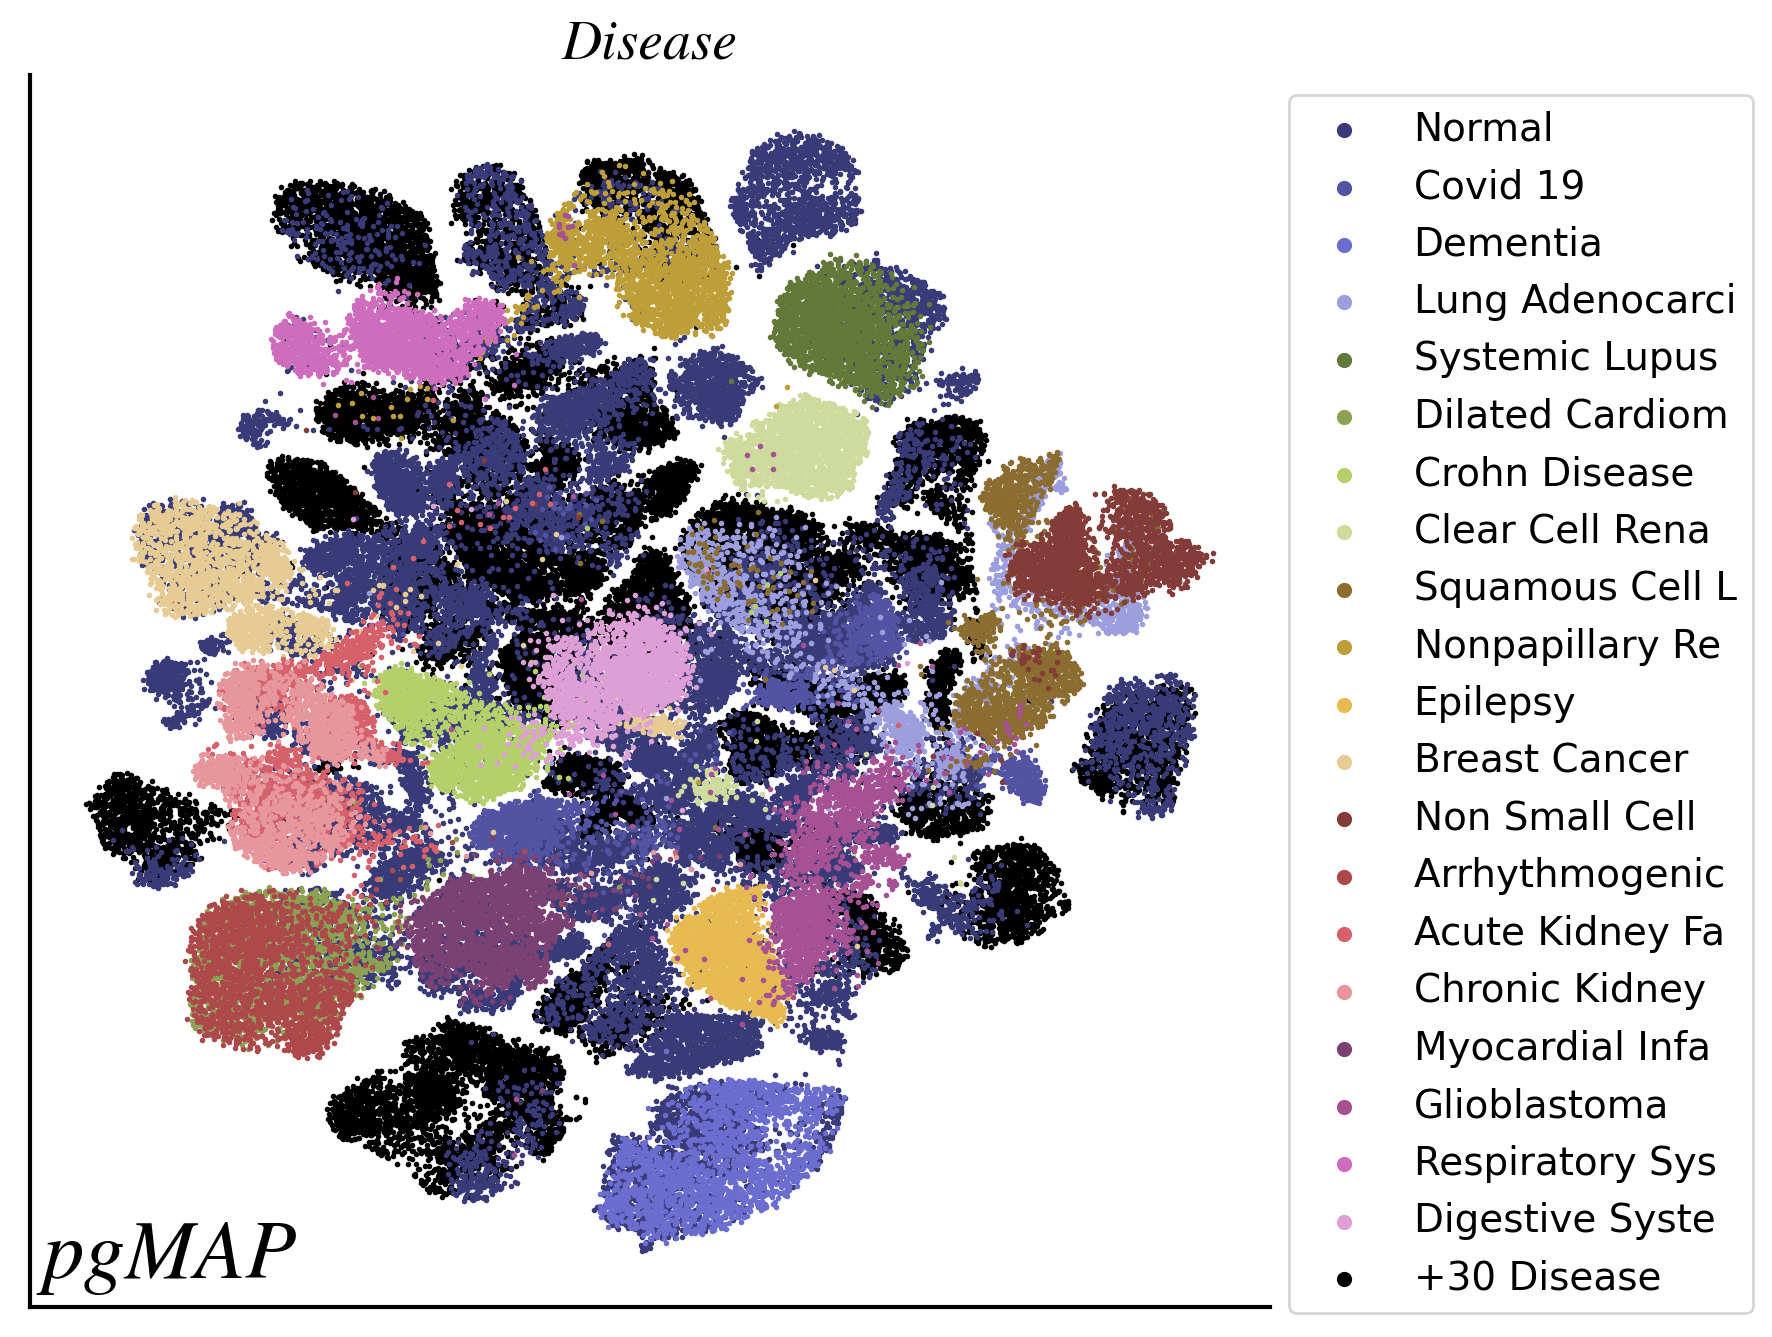

In [20]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import scanpy as sc

import os, sys, time
sys.path.append('../../')
from polygene.model.model import load_trained_model
from scipy.interpolate import CubicSpline

phenotypes = ["assay", "sex", "development_stage", "tissue", "disease", "cell_type"]

model_directory = '/media/lleger/LaCie/mit/runs/polygene_tied_linear_reconstruct/'
model, tokenizer = load_trained_model(model_directory)
fontsize=14
def radial_spline(df: pd.DataFrame, figsize=(8,8), radial_limits=None, samples=1000, every_other=0, phenotype="", save_path=None, dpi=100):
    theta = np.linspace(0, 2*np.pi, df.shape[0], endpoint=False)
    rmin = 0 if radial_limits is None else radial_limits[0]
    rmax = (np.nanmax(df.values) if radial_limits is None else radial_limits[1])
    fig, ax = plt.subplots(subplot_kw={"projection":"polar"}, figsize=figsize, dpi=dpi)
    for ang in theta: ax.plot([ang, ang], [rmin, 1.3*rmax], lw=1, ls=":", color="0.6")
    palette = sns.color_palette("cubehelix", 10)#['k' for _ in range(4)] #sns.color_palette("Set2", 4)
    styles = { 
                'f1': {'color': palette[1], 'ls': '-', 'alpha':1, 'lw':4},
                'recall@3': {'color': palette[6], 'ls': '-', 'alpha':1, 'lw':2},
                'recall': {'color': palette[2], 'ls': '-', 'alpha':1, 'lw': 2},
                'precision': {'color': palette[3], 'ls': '--', 'alpha':1, 'lw': 2}
                }
    masked = False
    for idx, (name, values) in enumerate(df.items()):
        cs = CubicSpline(np.r_[theta, theta[0]+2*np.pi], np.r_[values.values, values.values[0]], bc_type="periodic")
        tt = np.linspace(0, 2*np.pi, samples, endpoint=False)
        if "M_g" in name:
            palette = sns.color_palette('Purples', n_colors=df.shape[1])
            #palette = sns.color_palette('BuPu', n_colors=df.shape[1])
            #palette = sns.color_palette('Purples_r', n_colors=df.shape[1])
            ax.plot(tt, cs(tt), lw=2, label=name.capitalize().replace('M_g', '$Mask_{G}$ ='), color=palette[idx], ls='-', alpha=1)
            masked=True
        else:
            ax.plot(tt, cs(tt), lw=styles[name].get('lw', 1), label=name.capitalize(), color=styles[name]['color'], ls=styles[name]['ls'], alpha=styles[name]['alpha'])

    for idx, (ang, lbl) in enumerate(zip(theta, df.index.astype(str))):
        ax.text(ang, 1.2*rmax, f"{df.loc[lbl, 'f1']:.3f}" if not masked else f"{df.iloc[idx, df.shape[1]//2 - 1]:.3f}", ha="center", va="center",fontsize=fontsize)
        #if every_other > 0 and idx % every_other != 1: continue
        align = "right" if (np.cos(ang) < 0) else 'left'
        visual_lbl =  ' '.join([w.capitalize() for w in  lbl[1:-1].split('_')[:3]]) if not "F1" in phenotype else lbl
        ax.text(ang, rmax*1.4, visual_lbl, ha=align, va="center",fontsize=fontsize)
    
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1), frameon=False, fontsize=fontsize)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines['polar'].set_visible(False)
    ax.set_ylim(rmin, 1.5*rmax)
    ax.set_title(label=' '.join(phenotype.split('_')).title(), fontsize= fontsize)
    plt.tight_layout()
    if save_path is not None: 
        #os.makedirs('/'.join(save_path.split('/')[:-1]), exist_ok=True)
        plt.savefig(save_path, dpi=dpi)
    plt.show()

plotting_artifacts = pd.read_pickle(model_directory + "plotting_artifacts/plotting_artifacts.pkl")
print(plotting_artifacts['attention_umap'].shape)
for phenotype in tokenizer.phenotypic_types:
    metrics = plotting_artifacts["metrics_" + phenotype]
    metrics = metrics[metrics['f1'] > .8].head(25).sample(frac=1, random_state=4)
    if metrics.empty: continue
    #radial_spline(metrics, samples=500, every_other=0, phenotype=phenotype, save_path=f"{phenotype}_metrics.png", figsize=(12, 8), dpi=200)

for projection in ['attention_umap']:
    fontsize=14
    dpi=200
    gene_expression = plotting_artifacts.get(projection, None)
    if gene_expression is None: continue
    #for category in tokenizer.phenotypic_types:
    for category in ['disease']:
        save_path=f"{category}_{projection}.png"
        
        #if category != "disease": continue
        fig, ax = plt.subplots(1, 1, figsize=(8,8), dpi=dpi)
        classes = np.array([label for label in plotting_artifacts['labels']])[:, tokenizer.phenotypic_types.index(category)]
        unique_classes = pd.Series(classes).value_counts().index.tolist()
        
        max_colors = 20
        palette = sns.color_palette("Paired", n_colors=max_colors)
        palette = sns.color_palette("tab20b", n_colors=max_colors)
        
        size=1
        for idx, cls in enumerate(unique_classes[:max_colors]):
            class_gene_expression = gene_expression[classes == cls]
            ax.scatter(class_gene_expression[:, 0], class_gene_expression[:, 1], 
                    color=palette[idx], label=' '.join(cls[1:-1].split('_')).title()[:15], s=size)
        
        title = ' '.join(category.split('_')).capitalize()
        if len(unique_classes) > max_colors:
            remaining_classes = unique_classes[max_colors:]
            remaining_gene_expression = gene_expression[np.isin(classes, remaining_classes)]
            ax.scatter(remaining_gene_expression[:, 0], remaining_gene_expression[:, 1], 
                    color='k',alpha=1, label=f'+{len(remaining_classes)} {title}', s=size, zorder=-10)
        
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['bottom', 'left']].set_linewidth(1.5)
        ax.set_xlabel(''); ax.set_ylabel('')
        ax.set_xticks([]); ax.set_yticks([])
        legend = ax.legend(frameon=True,  framealpha=0.8, fontsize=fontsize, bbox_to_anchor =(1, 1))#, loc="lower right")
        for handle in legend.legendHandles:
            handle.set_sizes([20])
        ax.set_title(title,  fontsize=fontsize+6, 
            style="italic", fontfamily="TeX Gyre Termes")#fontsize=fontsize)
        ax.text(x=0.01, y=0.01, 
            s="UMAP" if projection == "umap" else "pgMAP", 
            ha="left", va="bottom",
            transform=ax.transAxes,
            fontsize=30, 
            style="italic", fontfamily="TeX Gyre Termes")
        if save_path is not None:# ...
            #os.makedirs('/'.join(save_path.split('/')[:-1]), exist_ok=True)
            plt.savefig(save_path, dpi=dpi)
        plt.show()

In [1]:
# representation alignment compute RA for all models versus number of cells with scatter of model size number of parameters

plato_experiment_path = "/media/lleger/LaCie/mit/disease_geometry/plato/"
import os
model_paths = sorted([path for path in os.listdir(plato_experiment_path) if len(os.listdir(plato_experiment_path + path)) > 10 and "TIED" not in path])


import scanpy as sc
import pandas as pd, numpy as np

import sys
sys.path.append('../../')
from polygene.model.model import load_trained_model

checkpoints = [checkpoint for checkpoint in os.listdir(plato_experiment_path + model_paths[0]) if "checkpoint" in checkpoint]
n_checkpoints = len(checkpoints)
print("n_checkpoints:", n_checkpoints)

tokenizer = pd.read_pickle(plato_experiment_path + model_paths[0] + "/tokenizer.pkl")
batch_size = tokenizer.config.per_device_train_batch_size
print("batchsize:", batch_size)
saved_steps = [int(checkpoint.split('-')[1]) for checkpoint in checkpoints]
print("saved training steps:", saved_steps)
print("number of cells seen", np.array(saved_steps)*batch_size)

test_data_path = '/media/lleger/LaCie/mit/disease_geometry/dataset/representation_test_shard0.h5ad'
test_cells = sc.read_h5ad(test_data_path)
print(test_cells.shape,)
models = [load_trained_model(plato_experiment_path + path + "/")[0] for path in model_paths]
reference_model = "polygene_seed_3_layers_6_dim_384"

def count_model_parameters(model, exclude = "embedding"):
    return sum(parameter.numel() for name, parameter in model.named_parameters() if exclude not in name)# / 1_000_000:.2f}M")
number_of_parameters = [count_model_parameters(model, exclude="blank") for model in models]
complexity_df = pd.DataFrame(list(zip(model_paths, number_of_parameters)), columns=["name", "complexity"])
display(complexity_df)

representations = pd.read_pickle("/media/lleger/LaCie/mit/disease_geometry/plato.pkl")

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


n_checkpoints: 14
batchsize: 32
saved training steps: [3125, 5212, 8695, 14504, 24195, 40360, 67326, 112306, 187338, 312500, 400000, 500000, 600000, 700000]
number of cells seen [  100000   166784   278240   464128   774240  1291520  2154432  3593792
  5994816 10000000 12800000 16000000 19200000 22400000]
(5000, 60664)


,name,complexity
0,polygene_seed_1_layers_6_dim_384,30758355
1,polygene_seed_2_layers_6_dim_384,30758355
2,polygene_seed_3_layers_1_dim_384,24838995
3,polygene_seed_3_layers_3_dim_384,27206739
4,polygene_seed_3_layers_6_dim_192,13536531
5,polygene_seed_3_layers_6_dim_384,30758355
6,polygene_seed_3_layers_6_dim_96,6308019


In [2]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import pairwise_distances
import numpy as np
checkpoints_to_exclude = [10, 12]

def cka_linear(X, Y):
    # Centered Kernel Alignment
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    return np.sum(K*L)/np.sqrt(np.sum(K*K)*np.sum(L*L))

def mutual_knn(X, Y):
    # Mutual Nearest Neighbors
    k =  int(0.01*len(X))
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

def representation_alignment(X, Y):
    # RA: harmonic mean of CKA and MKNN (similar to F1 score)
    cka = cka_linear(X, Y)
    mknn = mutual_knn(X, Y)
    if cka + mknn == 0:
        return 0
    return 2 * cka * mknn / (cka + mknn)

number_of_cells_seen = np.array(saved_steps)*batch_size
number_of_cells_seen = np.delete(number_of_cells_seen, checkpoints_to_exclude)
print(f"Number of checkpoints: {len(number_of_cells_seen)}")

reference_representations = np.stack(representations[reference_model]).reshape(len(number_of_cells_seen), 2500, -1)[-1]
print(f"Reference representations shape: {reference_representations.shape}")

# Compute RA for all models and checkpoints
ra_results = []

for model_key in representations:
    print(f"Processing {model_key}...")
    if model_key == reference_model: 
        continue
    
    X = np.stack(representations[model_key]).reshape(len(number_of_cells_seen), 2500, -1)
    model_complexity = complexity_df[complexity_df['name'] == model_key]['complexity'].values[0]
    
    for checkpoint_idx in range(len(number_of_cells_seen)):
        cka = cka_linear(X[checkpoint_idx], reference_representations)
        mknn = mutual_knn(X[checkpoint_idx], reference_representations)
        ra = representation_alignment(X[checkpoint_idx], reference_representations)
        
        ra_results.append({
            'model': model_key,
            'checkpoint': checkpoint_idx,
            'n_cells': number_of_cells_seen[checkpoint_idx],
            'complexity': model_complexity,
            'CKA': cka,
            'MKNN': mknn,
            'RA': ra
        })
        print(f"  Checkpoint {checkpoint_idx}: RA={ra:.4f}, CKA={cka:.4f}, MKNN={mknn:.4f}")

ra_df = pd.DataFrame(ra_results)
print(f"\nTotal data points: {len(ra_df)}")
display(ra_df.head(20))

Number of checkpoints: 12
Reference representations shape: (2500, 384)
Processing polygene_seed_1_layers_6_dim_384...
  Checkpoint 0: RA=0.1987, CKA=0.2685, MKNN=0.1578
  Checkpoint 1: RA=0.3367, CKA=0.6450, MKNN=0.2278
  Checkpoint 2: RA=0.1920, CKA=0.2429, MKNN=0.1588
  Checkpoint 3: RA=0.2716, CKA=0.4719, MKNN=0.1906
  Checkpoint 4: RA=0.2224, CKA=0.3888, MKNN=0.1557
  Checkpoint 5: RA=0.1889, CKA=0.2408, MKNN=0.1554
  Checkpoint 6: RA=0.1895, CKA=0.2424, MKNN=0.1556
  Checkpoint 7: RA=0.2286, CKA=0.3406, MKNN=0.1721
  Checkpoint 8: RA=0.1904, CKA=0.2412, MKNN=0.1572
  Checkpoint 9: RA=0.2907, CKA=0.4731, MKNN=0.2098
  Checkpoint 10: RA=0.2097, CKA=0.2862, MKNN=0.1654
  Checkpoint 11: RA=0.5159, CKA=0.9075, MKNN=0.3604
Processing polygene_seed_2_layers_6_dim_384...
  Checkpoint 0: RA=0.1945, CKA=0.2560, MKNN=0.1568
  Checkpoint 1: RA=0.3457, CKA=0.6441, MKNN=0.2363
  Checkpoint 2: RA=0.1829, CKA=0.2263, MKNN=0.1534
  Checkpoint 3: RA=0.2617, CKA=0.4376, MKNN=0.1867
  Checkpoint 4: R

,model,checkpoint,n_cells,complexity,CKA,MKNN,RA
0,polygene_seed_1_layers_6_dim_384,0,100000,30758355,0.268473,0.15776,0.198738
1,polygene_seed_1_layers_6_dim_384,1,166784,30758355,0.645001,0.22784,0.336733
2,polygene_seed_1_layers_6_dim_384,2,278240,30758355,0.242873,0.15880,0.192038
3,polygene_seed_1_layers_6_dim_384,3,464128,30758355,0.471904,0.19064,0.271571
4,polygene_seed_1_layers_6_dim_384,4,774240,30758355,0.388822,0.15572,0.222379
5,polygene_seed_1_layers_6_dim_384,5,1291520,30758355,0.240816,0.15544,0.188930
6,polygene_seed_1_layers_6_dim_384,6,2154432,30758355,0.242434,0.15556,0.189515
7,polygene_seed_1_layers_6_dim_384,7,3593792,30758355,0.340585,0.17208,0.228640
8,polygene_seed_1_layers_6_dim_384,8,5994816,30758355,0.241242,0.15720,0.190358
9,polygene_seed_1_layers_6_dim_384,9,10000000,30758355,0.473114,0.20976,0.290655


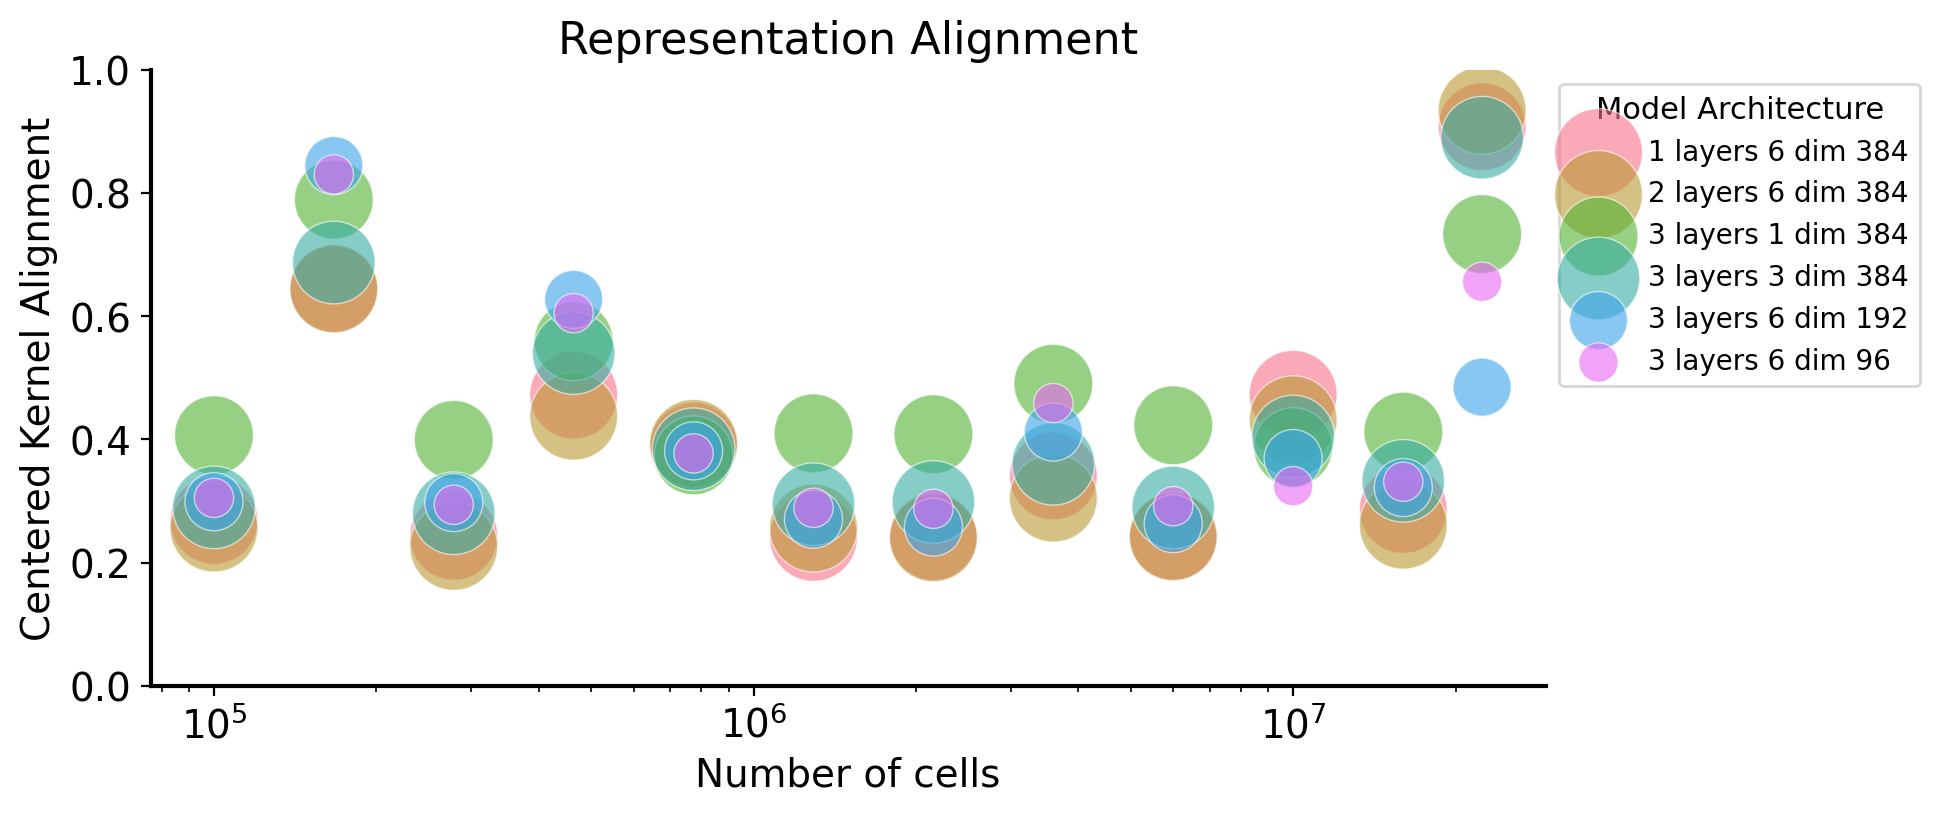

In [ ]:
# Create scaling laws plot: RA vs number of cells, with scatter size representing model complexity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(9, 4), dpi=200)

# Get unique models and assign colors
unique_models = ra_df['model'].unique()
palette = sns.color_palette("husl", n_colors=len(unique_models))
model_colors = {model: palette[i] for i, model in enumerate(unique_models)}

min_complexity = ra_df['complexity'].min()
max_complexity = ra_df['complexity'].max()
min_size = 200
max_size = 1000

# Plot each model
for model in unique_models:
    model_data = ra_df[ra_df['model'] == model].sort_values('n_cells')
    
    # Normalize sizes based on complexity
    sizes = ((model_data['complexity'] - min_complexity) / (max_complexity - min_complexity)) * (max_size - min_size) + min_size
    
    # Create scatter plot
    scatter = ax.scatter(
        model_data['n_cells'], 
        model_data['CKA'],
        s=sizes,
        color=model_colors[model],
        alpha=0.6,
        edgecolors='white',
        linewidths=0.5,
        label=model.replace('polygene_seed_', '').replace('_', ' ')
    )

# Set log scale for x-axis (number of cells)
ax.set_xscale('log')

# Labels and title
ax.set_xlabel('Number of cells', fontsize=14)
ax.set_ylabel('Centered Kernel Alignment', fontsize=14)
ax.set_title('Representation Alignment', fontsize=16)

# Legend for models

# Create dummy legend for sizes (complexity)
complexity_values = [min_complexity, (min_complexity + max_complexity) / 2, max_complexity]
complexity_labels = [f'{int(c/1e6)}M' for c in complexity_values]
size_values = [min_size, (min_size + max_size) / 2, max_size]

dummy_handles = [plt.scatter([], [], s=s, color='gray', alpha=0.6, edgecolors='white', linewidths=0.5) 
                 for s in size_values]
legend2 = ax.legend(dummy_handles, complexity_labels, 
                   loc='lower left', bbox_to_anchor=(1.02, 0),
                   frameon=True, fontsize=10, title='Parameters',
                   title_fontsize=11)

legend1 = ax.legend(loc='upper left', bbox_to_anchor=(1, 1), 
                    frameon=True, fontsize=10, title='Model Architecture',
                    title_fontsize=11)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(1.5)
ax.tick_params('both', labelsize=14)


#plt.tight_layout()

plt.show()

# 
# Representation Alignment = CKA * MKNN

In [ ]:
# Process data
import pandas as pd
from scipy.spatial import procrustes
import numpy as np, pandas as pd
from sklearn.metrics import pairwise_distances

def cka_linear(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    return np.sum(K*L)/np.sqrt(np.sum(K*K)*np.sum(L*L))

def mutual_knn(X, Y,):
    k = int(0.01*len(X))
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

X = pd.read_pickle(SEEDS_EXPERIMENT_PATH + "representations.pkl")[:-1]

print('Learned representations shape', [mat.shape for mat in X])
import itertools
scores = []
for idx, (x_mat, y_mat) in enumerate(itertools.combinations(X, r=2)):
    s = []
    print("Combinations:\n", idx)
    #for n, func in zip([ 'Mutual kNN'], [ mutual_knn]):
    for n, func in zip(['CKA', 'Mutual kNN'], [cka_linear, mutual_knn]):
        value = func(x_mat, y_mat)
        print(n, round(func(x_mat, y_mat), 4))
        if n in ['CKA', 'Mutual kNN']: s.append(value)
    scores.append(s)

np.random.seed(3)
random_matrices = [np.random.uniform(size=X[0].shape) for _ in range(2)]
random_cka = cka_linear(random_matrices[0], random_matrices[1])
random_mknn = mutual_knn(random_matrices[0], random_matrices[1], )
baseline_performance = (2*random_cka*random_mknn)/(random_cka+random_mknn)
#baseline_performance=
print(baseline_performance, random_cka, random_mknn)


# Shared integral paths
### gradient flow curves similarity diminishes. take same cells

### 

In [ ]:
# Shared integral paths
### gradient flow curves similarity diminishes. take same cells
import os, sys, json
sys.path.append('../../')
import scanpy as sc
import copy
import pandas as pd, numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
from polygene.model.model import load_trained_model
from polygene.eval.metrics import prepare_cell
from polygene.data_utils.tokenization import normalise_str

frequent_diseases = json.load(open('/media/lleger/LaCie/mit/disease_geometry/diseases.json'))['diseases']; print(len(frequent_diseases), "diseases")
lung_cancers = [disease for disease in frequent_diseases if "lung" in disease and "carcinoma" in disease]
print(lung_cancers)

data_dir = "/media/lleger/LaCie/mit/disease_geometry/dataset/healthy_lung_cells.h5ad"
healthy_lung_cells = sc.read_h5ad(data_dir)[:100]
print(healthy_lung_cells.shape)

neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_tied_linear_reconstruct/"
model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-2) # highest performance model
decoder = model.prediction_head[-1] # embedding matrix,
latent_map = copy.deepcopy(model.prediction_head) # copying layer norm
latent_map[-1] = nn.Identity()
print("decoder from latent to probability simplex and exponential probability distribution parameters", decoder)

log_partition_function = lambda xi: torch.log( torch.sum( torch.exp( xi ) ) )

disease_representations = decoder.weight.detach().cpu().numpy()[[tokenizer.flattened_tokens.index(normalise_str(disease)) for disease in lung_cancers], :]
print("fixed points of phase portrait", disease_representations.shape)

max_steps_of_integral_paths = 1000
step_size = 0.01
latent_embeddings = {}
gradient_flow_paths = {}

log_partition_function = lambda xi: torch.log( torch.sum( torch.exp( xi ) ) )

# the fisher rao metric is the second order taylor approximation of the KL divergence, it is the second derivative of the convex potential for natural parameters xi
def riemannian_metric(z, decoder):
    jacobian_decoder = torch.func.jacfwd(decoder)(z)
    hessian_log_partition = torch.func.hessian(log_partition_function)(decoder(z))
    G = jacobian_decoder.T @ hessian_log_partition @ jacobian_decoder
    return G

    

for cell in healthy_lung_cells:
    
    cell_dict, labels = prepare_cell(cell, tokenizer)
    # mask phenotypes
    phenotype_token_mask = tokenizer.get_phenotypic_tokens_mask(cell_dict['token_type_ids'])
    cell_dict['input_ids'][phenotype_token_mask] = tokenizer.token_to_id_map[tokenizer.mask_token]
    
    output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items()})
    z = latent_map(torch.concatenate(output.hidden_states['hidden_states'])[-1, 1 + tokenizer.phenotypic_types.index('disease')]).detach().requires_grad_(True)
    
    for idx, disease in enumerate(lung_cancers):
        gradient_flow_path = [z]
        disease_representation = torch.tensor(disease_representations[idx], device=model.device)
        disease_vocab_index = tokenizer.token_to_id_map[normalise_str(disease)]
        
        print(decoder(disease_representation).shape)
        for step in range(max_steps_of_integral_paths):
            print("\nerror:", torch.norm(gradient_flow_path[-1] - disease_representation).item())
            probability = torch.nn.functional.softmax( decoder(gradient_flow_path[-1]), dim=-1)
            print(probability[disease_vocab_index].item())
            print(probability.argmax(-1).item(), disease_vocab_index)
            
            decoder.zero_grad()
            probability[disease_vocab_index].backward(retain_graph=True)

            #G = riemannian_metric(gradient_flow_path[-1], decoder)
            #G = 0.5 * (G + G.T) + 1e-3 * torch.eye(G.shape[0], device=model.device)

            
            #gradient =  torch.linalg.solve(G, gradient_flow_path[-1].grad.detach())
            gradient = gradient_flow_path[-1].grad.detach()
            gradient = gradient / torch.norm(gradient)
            gradient_flow_path.append( (gradient_flow_path[-1] + step_size * gradient).detach().requires_grad_(True))
            #break
            
        break
        print(probability.shape)
    break


50 diseases
['lung adenocarcinoma', 'squamous cell lung carcinoma', 'non-small cell lung carcinoma', 'small cell lung carcinoma', 'lung large cell carcinoma']
(100, 60664)
decoder from latent to probability simplex and exponential probability distribution parameters Linear(in_features=240, out_features=1107, bias=False)
fixed points of phase portrait (5, 240)
torch.Size([1107])

error: 15.918150901794434
0.0007779209408909082
811 829

error: 15.913372993469238
0.0007812591502442956
811 829

error: 15.908604621887207
0.0007846093503758311
811 829

error: 15.903846740722656
0.0007879712502472103
811 829

error: 15.89909839630127
0.0007913449662737548
811 829

error: 15.89436149597168
0.0007947309641167521
811 829

error: 15.889634132385254
0.0007981287781149149
811 829

error: 15.884917259216309
0.0008015392231754959
811 829

error: 15.880210876464844
0.0008049613097682595
811 829

error: 15.875514030456543
0.0008083953289315104
811 829

error: 15.870827674865723
0.0008118417463265359
81

In [7]:
#lung_cancers = [disease for disease in frequent_diseases if "lung" in disease and "carcinoma" in disease]
#METADATA_PATH = '/media/rohola/ssd_storage/primary_metadata/'
#metadata = pd.concat([pd.read_pickle(METADATA_PATH+f) for f in sorted(os.listdir(METADATA_PATH))], ignore_index=True)
#print(lung_cancers)
#for disease in lung_cancers:
#    display(metadata[metadata['disease'] == disease].value_counts('cell_type').reset_index().head(5))
#
#metadata[metadata['tissue_general'] == "lung"].value_counts('cell_type').head(50)

In [ ]:
model_dir = '/media/lleger/LaCie/mit/runs/polygene_tied_linear_reconstruct/'
project_dir = '/media/lleger/LaCie/mit/disease_geometry/'
import json, os
import pandas as pd
os.listdir(project_dir)

disease_cell_types = json.load(open(project_dir + "cell_types_per_disease.json"))
disease_tissues = json.load(open(project_dir + "disease_tissues.json"))
diseases = json.load(open(project_dir + "diseases.json"))['diseases']
print(disease_tissues)

display(pd.DataFrame.from_dict(disease_tissues, orient='index').value_counts()) # main tissues: general tissues where the disease has the largest population of non immunological cells
disease_cell_types['normal']


#healthy lung epithelial cells

{'COVID-19': 'lung', 'glioblastoma': 'brain', 'dementia': 'brain', 'lung adenocarcinoma': 'lung', 'systemic lupus erythematosus': 'blood', 'dilated cardiomyopathy': 'heart', 'Crohn disease': 'small intestine', 'clear cell renal carcinoma': 'kidney', 'squamous cell lung carcinoma': 'lung', 'nonpapillary renal cell carcinoma': 'kidney', 'epilepsy': 'brain', 'breast cancer': 'breast', 'gastric cancer': 'stomach', 'non-small cell lung carcinoma': 'lung', 'arrhythmogenic right ventricular cardiomyopathy': 'heart', 'chronic kidney disease': 'kidney', 'acute kidney failure': 'kidney', 'follicular lymphoma': 'lymph node', 'myocardial infarction': 'heart', 'B-cell acute lymphoblastic leukemia': 'blood', 'blastoma': 'liver', 'Parkinson disease': 'brain', 'B-cell non-Hodgkin lymphoma': 'bone marrow', 'plasma cell myeloma': 'bone marrow', 'respiratory system disorder': 'blood', 'post-COVID-19 disorder': 'blood', 'small cell lung carcinoma': 'lung', 'pulmonary fibrosis': 'lung', 'interstitial lung 

lung               11
brain               7
kidney              6
blood               6
small intestine     4
bone marrow         3
stomach             3
heart               3
breast              1
liver               1
mucosa              1
lymph node          1
prostate gland      1
nose                1
dtype: int64

[['epithelial cell of proximal tubule',
  'kidney',
  'acute kidney failure',
  'epithelial cell of proximal tubule'],
 ['native cell', 'small intestine', 'adenocarcinoma', 'colon goblet cell'],
 ['kidney loop of Henle thick ascending limb epithelial cell',
  'kidney',
  'chronic kidney disease',
  'kidney loop of Henle thick ascending limb epithelial cell'],
 ['stem cell', 'stomach', 'gastric intestinal metaplasia', 'stem cell'],
 ['kidney collecting duct principal cell',
  'kidney',
  'chronic kidney disease',
  'kidney collecting duct principal cell'],
 ['CD8-positive, alpha-beta cytotoxic T cell',
  'blood',
  'post-COVID-19 disorder',
  'CD8-positive, alpha-beta cytotoxic T cell'],
 ['fibroblast', 'kidney', 'kidney oncocytoma', 'fibroblast'],
 ['cardiac muscle cell',
  'heart',
  'arrhythmogenic right ventricular cardiomyopathy',
  'cardiac muscle cell'],
 ['plasma cell', 'bone marrow', 'plasma cell myeloma', 'plasma cell'],
 ['kidney loop of Henle thick ascending limb epithelial 